## Drones 2

#### I. Initialisation

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle

In [3]:
#Animation

import time
from IPython.display import clear_output

#### II. Graph

##### a) Génère un graphe

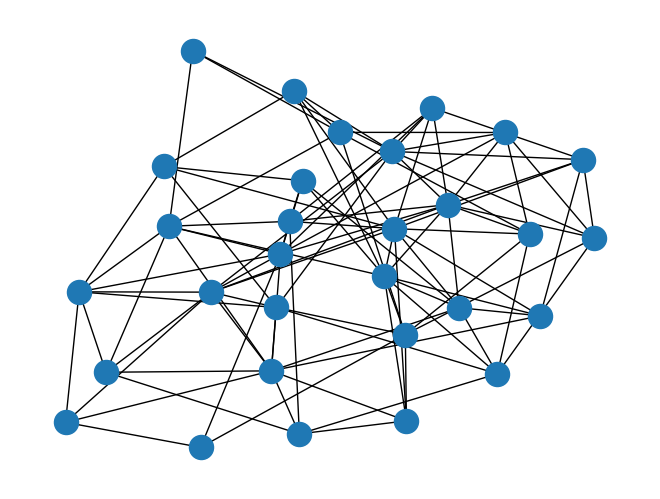

In [4]:
n = 30
p = 0.2  

connected = False
while not connected:
    G = nx.erdos_renyi_graph(n, p)
    connected = nx.is_connected(G)

nx.draw(G)

##### b) Est-il eulérien ?

In [5]:
print("Ce graphe est eulerien :", nx.is_eulerian(G))

Ce graphe est eulerien : False


##### c) Rendons-le eulérien

In [6]:
H = nx.eulerize(G)
print("Ce graphe est eulerien :", nx.is_eulerian(H))

Ce graphe est eulerien : True


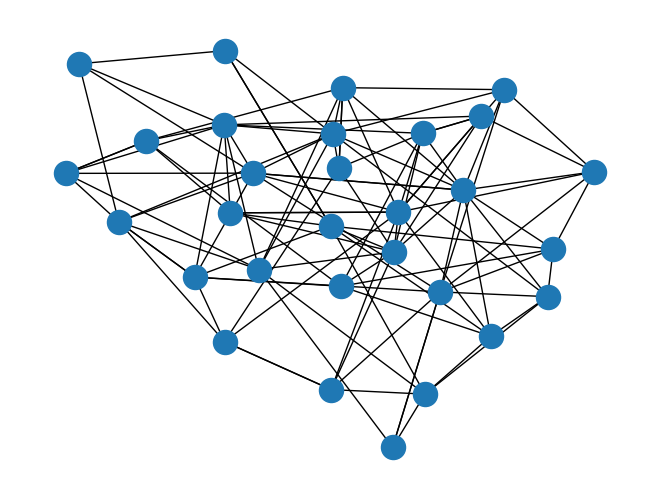

In [7]:
nx.draw(H)
#list(nx.eulerian_circuit(H))

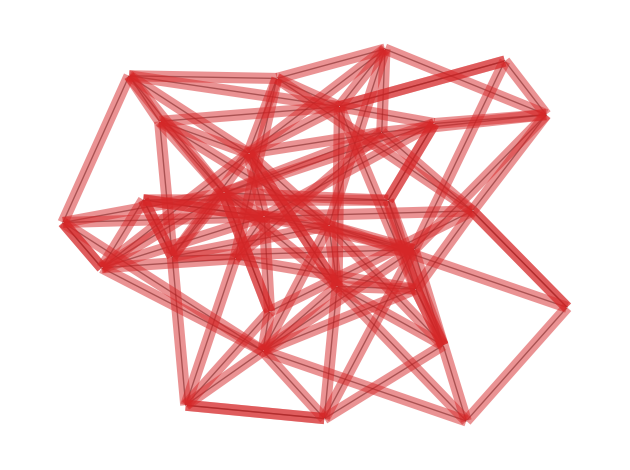

In [8]:
pos = nx.spring_layout(H)  # positions for all nodes

# nodes
options = {"edgecolors": "tab:gray", "node_size": 0, "alpha": 0.9}
nx.draw_networkx_nodes(H, pos, nodelist=G.nodes(), node_color="tab:blue", **options)


# edges
nx.draw_networkx_edges(H, pos, width=1.0, alpha=0.5)
nx.draw_networkx_edges(
    H,
    pos,
    edgelist=list(nx.eulerian_circuit(H)),
    width=8,
    alpha=0.5,
    edge_color="tab:red",
)

nx.draw_networkx_labels(H, pos, font_size=0, font_color="whitesmoke")

plt.tight_layout()
plt.axis("off")
plt.show()

#### III. Animation

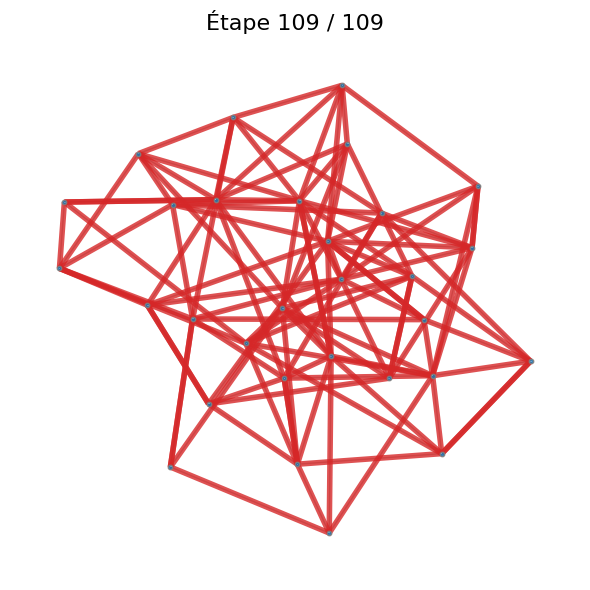

In [9]:
pos = nx.spring_layout(H, seed=42)

circuit = list(nx.eulerian_circuit(H))

edges_drawn = []

for i, edge in enumerate(circuit):
    edges_drawn.append(edge)

    clear_output(wait=True)
    plt.figure(figsize=(6, 6))

    options = {"edgecolors": "tab:gray", "node_size": 10, "alpha": 0.9}
    nx.draw_networkx_nodes(H, pos, node_color="tab:blue", **options)

    nx.draw_networkx_edges(H, pos, width=1.0, alpha=0.3)

    nx.draw_networkx_edges(
        H,
        pos,
        edgelist=edges_drawn,
        width=4,
        alpha=0.8,
        edge_color="tab:red",
    )

    
    nx.draw_networkx_labels(H, pos, font_size=0, font_color="whitesmoke")

    plt.title(f"Étape {i+1} / {len(circuit)}", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



#### IV. Postier Chinois
Notre circuit est stupide ! Il ne prend pas en compte le poids des arêtes...

In [10]:
G_bis = nx.MultiGraph(G)

for u, v in G.edges():
    for key in G_bis[u][v]:
        G_bis[u][v][key]['weight'] = round(random.uniform(1, 10), 2)
        G_bis[u][v][key]['snow'] = random.randint(0,1)

# Trouver les sommets de degre impair
odd_nodes = [v for v, d in G_bis.degree() if d % 2 == 1]

# Generer tous les appariements possibles (pairs sans repetition)
pairs = list(itertools.combinations(odd_nodes, 2))

# Calculer la distance la plus courte entre chaque paire
pair_weights = {}
for u, v in pairs:
    length = nx.dijkstra_path_length(G_bis, u, v, weight='weight')
    pair_weights[(u, v)] = length

# Trouver les chemins de distance minimale pour chaque paire de nœuds
neg_weights = {pair: -w for pair, w in pair_weights.items()}

# Graphe reliant tous les sommets deux à deux avec comme poids l'opposé de leur distance
matching_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])

# Choisit les arêtes à doubler qui minimise la distance totale
matching = max_weight_matching(matching_graph, maxcardinality=True)

# Ajouter les aretes necessaires (dans un MultiGraph)
G_aug = nx.MultiGraph(G)  # copie avec aretes multiples autorisees
for u, v in matching:
    path = nx.dijkstra_path(G, u, v, weight='weight')
    path_edges = list(zip(path[:-1], path[1:]))
    for edge in path_edges:
        weight = G_bis[edge[0]][edge[1]][0]['weight']
        G_aug.add_edge(edge[0], edge[1], weight=weight)


# Maintenant que tous les sommets ont un degre pair, on peut trouver un circuit eulerien
print("Ce graphe est eulerien :", nx.is_eulerian(G_aug))
circuit = list(nx.eulerian_circuit(G_aug))

Ce graphe est eulerien : True


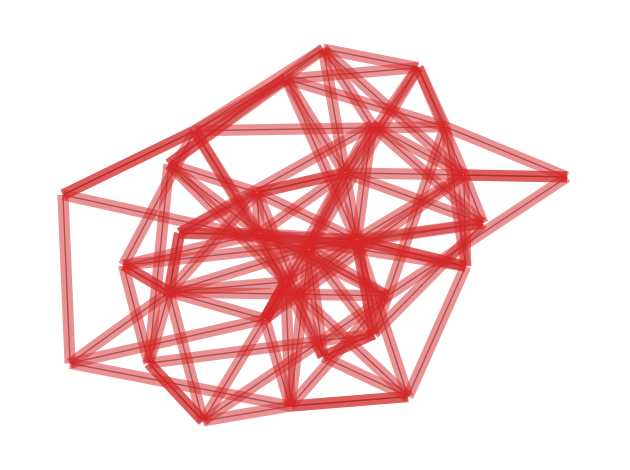

In [11]:
pos = nx.spring_layout(G_aug)  # positions pour tous les nœuds

# nodes
options = {"edgecolors": "tab:gray", "node_size": 0, "alpha": 0.9}
nx.draw_networkx_nodes(G_aug, pos, nodelist=G.nodes(), node_color="tab:blue", **options)


# edges
nx.draw_networkx_edges(G_aug, pos, width=1.0, alpha=0.5)
nx.draw_networkx_edges(
    G_aug,
    pos,
    edgelist=list(nx.eulerian_circuit(G_aug)),
    width=8,
    alpha=0.5,
    edge_color="tab:red",
)

nx.draw_networkx_labels(G_aug, pos, font_size=0, font_color="whitesmoke")

plt.tight_layout()
plt.axis("off")
plt.show()

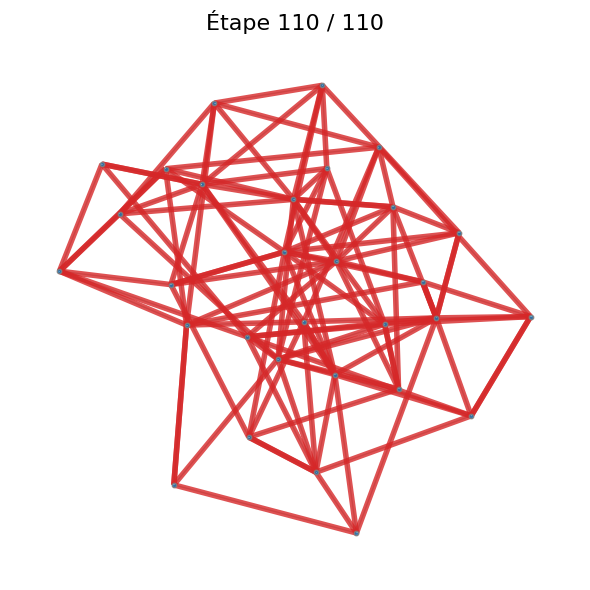

In [12]:
pos = nx.spring_layout(G_aug, seed=42)

circuit = list(nx.eulerian_circuit(G_aug))

edges_drawn = []

for i, edge in enumerate(circuit):
    edges_drawn.append(edge)

    clear_output(wait=True)
    plt.figure(figsize=(6, 6))

    options = {"edgecolors": "tab:gray", "node_size": 10, "alpha": 0.9}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)

    nx.draw_networkx_edges(G_aug, pos, width=1.0, alpha=0.3)

    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=edges_drawn,
        width=4,
        alpha=0.8,
        edge_color="tab:red",
    )
        
    nx.draw_networkx_labels(G_aug, pos, font_size=0, font_color="whitesmoke")

    plt.title(f"Étape {i+1} / {len(circuit)}", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    time.sleep(0.3)

#### V.Comparaison

In [38]:
def dist(G, circuit):
    total = 0

    for u, v in circuit:
        edge_dict = G[u][v]
        key = next(iter(edge_dict))
        weight = edge_dict[key].get('weight', 1)
        total += weight
    
    return total

In [39]:
print("distance 1:", dist(G_bis, list(nx.eulerian_circuit(H))))
print("distance 2:", dist(G_bis, list(nx.eulerian_circuit(G_aug))))

distance 1: 237.98999999999992
distance 2: 237.98999999999992
